In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', None)

# Load data
df_pan = pd.read_csv("C:\\Users\\Acer\\Downloads\\COMP4501-FYP\\eda_combined\\data\\pan_final.csv")
df_sandal = pd.read_csv("C:\\Users\\Acer\\Downloads\\COMP4501-FYP\\eda_combined\\data\\sandal_final.csv")
df_sunscreen = pd.read_csv("C:\\Users\\Acer\\Downloads\\COMP4501-FYP\\eda_combined\\data\\sunscreen_final.csv")
df_wallet = pd.read_csv("C:\\Users\\Acer\\Downloads\\COMP4501-FYP\\eda_combined\\data\\wallet_final.csv")

## Load Data

In [92]:
# Load data
#df_pan = pd.read_csv("../datasets/final_data/pan_final.csv")
#df_sandal = pd.read_csv("../datasets/final_data/sandal_final.csv")
#df_sunscreen = pd.read_csv("../datasets/final_data/sunscreen_final.csv")
#df_wallet = pd.read_csv("../datasets/final_data/wallet_final.csv")

## Config

In [93]:
import numpy as np

CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "val_size": 0.2,
    "cv_folds": 5,

    "stage2_trials": 100,

    "target_cols": ["z_sold", "z_rating_credibility"],

    "metrics": ["rmse", "mae", "r2"]
}

## Data Split

In [94]:
from sklearn.model_selection import train_test_split

def split_data(df, config):
    train_val, test = train_test_split(
        df,
        test_size=config["test_size"],
        random_state=config["random_seed"]
    )

    train, val = train_test_split(
        train_val,
        test_size=config["val_size"],
        random_state=config["random_seed"]
    )

    return train, val, test

## Feature Type Detection

In [95]:
def detect_feature_types(df):
    numeric = []
    categorical = []
    binary = []

    for col in df.columns:

        # skip ID-like columns where it has many unique values as rows
        if df[col].dtype == "object" and df[col].nunique() > 0.9 * len(df):
            continue
        
        # detect binary features (usually contains 0 or 1)
        if df[col].nunique() == 2: 
            binary.append(col)

        # convert to numeric if possible
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric.append(col)

        else:
            categorical.append(col)

    return numeric, categorical, binary

def select_features(df):
    cols = df.columns.tolist()

    drop_cols = {
        "target",
        "title",
        "sold",
        "reviews",
        "gmv_cal",
        "rating",
        "rating_credibility",
        "z_sold",
        "z_rating_credibility",
        "id",
        "seller_name"
    }

    drop_log_related = {
        "log_sold",
        "log_reviews",
        "log_gmv_cal"
    }

    selected = []

    for c in cols:
        if c in drop_cols or c in drop_log_related:
            continue

        selected.append(c)

    return selected

## Feature Split (Between Log and Non-Log)

In [96]:
def split_features_by_model(df, num_cols):

    log_cols = [c for c in num_cols if c.startswith("log_")]

    raw_cols = []
    for c in log_cols:
        raw = c.replace("log_", "")
        if raw in df.columns:
            raw_cols.append(raw)

    # numeric that are not log or raw pairs
    other_numeric = [
        c for c in num_cols
        if not c.startswith("log_") and c not in raw_cols
    ]

    return log_cols, raw_cols, other_numeric

## Target Engine (PCA + Bootstrap)

In [97]:
from sklearn.decomposition import PCA

def bootstrap_pca_weights(train, cols, n_boot=200):
    weights = []

    X = train[cols].values

    for _ in range(n_boot):
        # sample row of X
        idx = np.random.choice(len(X), len(X), replace=True)
        sample = X[idx]

        # fit PCA on sample
        pca = PCA(n_components=1)
        pca.fit(sample)

        w = pca.components_[0]

        # Align sign
        if w[0] < 0:
            w = -w

        weights.append(w)

    weights = np.array(weights)

    mean_w = weights.mean(axis=0)
    std_w = weights.std(axis=0)

    return mean_w, std_w


def create_target(df, weights, cols):
    return df[cols].values @ weights

## Preprocessing Pipelines

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate the columns for linear and tree models
# Convert categorical features to one-hot encoding for model that can't process categorical features directly
def build_linear_pipeline(df, num_cols, cat_cols):

    log_cols, _, other_numeric = split_features_by_model(df, num_cols)

    linear_num_cols = log_cols + other_numeric

    print("\n[DEBUG] Linear features:")
    print(linear_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, linear_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])


def build_tree_pipeline(df, num_cols, cat_cols):

    log_cols, raw_cols, other_numeric = split_features_by_model(df, num_cols)

    tree_num_cols = raw_cols + other_numeric

    print("\n[DEBUG] Tree features:")
    print(tree_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, tree_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

## List of Models

In [99]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor


def get_models():
    return {
        # Baselines (to see if there is any linear relationship, and to check if more complex models are needed)
        "linear_regression": LinearRegression(),
        "ridge": Ridge(),
        "lasso": Lasso(),
        "elastic_net": ElasticNet(),

        # Tree Models
        "random_forest": RandomForestRegressor(),
        "extra_trees": ExtraTreesRegressor(),

        # Boosting 
        "xgboost": xgb.XGBRegressor(tree_method="hist"),
        "lightgbm": lgb.LGBMRegressor(verbosity=-1),
        "catboost": CatBoostRegressor(verbose=0),

        # Others
        "svr": SVR(),
        "knn": KNeighborsRegressor()
    }

## Evaluation Metrics

In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

## Stage 1 - Fast Screening

In [101]:
from sklearn.model_selection import cross_validate

def stage1_search(models, X, y, preprocessors, config):

    results = []

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    for name, model in models.items():

        pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring=scoring,
            return_train_score=False
        )

        results.append({
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_sd": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean()
        })

    # sort
    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean")

    # select top models
    top_models = results_df.head(3).to_dict("records")

    return top_models, results_df

## Stage 2 - Optuna Tuning

In [102]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def tune_model(model_name, X, y, preprocessor, config):

    def objective(trial):

        # Linear Models
        if model_name == "linear_regression":
            model = LinearRegression()

        elif model_name == "ridge":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)
            }
            model = Ridge(**params)

        elif model_name == "lasso":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)
            }
            model = Lasso(**params)

        elif model_name == "elastic_net":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
                "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
            }
            model = ElasticNet(**params)

        # Tree Models
        elif model_name == "random_forest":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
            }
            model = RandomForestRegressor(**params)

        elif model_name == "extra_trees":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
            }
            model = ExtraTreesRegressor(**params)

        # Boosting Models
        elif model_name == "xgboost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)
            }
            model = xgb.XGBRegressor(tree_method="hist", **params)

        elif model_name == "lightgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
                "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 50)
            }
            model = lgb.LGBMRegressor(**params, verbosity=-1)

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 800),
                "depth": trial.suggest_int("depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "border_count": trial.suggest_int("border_count", 32, 255)
            }
            model = CatBoostRegressor(**params, verbose=0)

        # SVR
        elif model_name == "svr":
            params = {
                "C": trial.suggest_float("C", 0.1, 100, log=True),
                "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
            }
            model = SVR(**params)

        # KNN
        elif model_name == "knn":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2)
            }
            model = KNeighborsRegressor(**params)

        else:
            raise ValueError(f"No tuning defined for {model_name}")

        # PIPELINE
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ])

        score = cross_val_score(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring="neg_root_mean_squared_error"
        ).mean()

        return -score

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=config["stage2_trials"])

    return study.best_params

## Build Model

In [103]:
def build_model(name, params):

    if name == "linear_regression":
        return LinearRegression(**params)

    elif name == "ridge":
        return Ridge(**params)

    elif name == "lasso":
        return Lasso(**params)

    elif name == "elastic_net":
        return ElasticNet(**params)

    elif name == "random_forest":
        return RandomForestRegressor(**params)

    elif name == "extra_trees":
        return ExtraTreesRegressor(**params)

    elif name == "xgboost":
        return xgb.XGBRegressor(tree_method="hist", **params)

    elif name == "lightgbm":
        return lgb.LGBMRegressor(**params, verbosity=-1)

    elif name == "catboost":
        return CatBoostRegressor(**params, verbose=0)

    elif name == "svr":
        return SVR(**params)

    elif name == "knn":
        return KNeighborsRegressor(**params)

    else:
        raise ValueError(f"Unknown model: {name}")

## Final Training

In [104]:
def train_final(model, preprocessor, X_train, y_train):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

## Weighted Ensemble Model

In [105]:
def weighted_ensemble(preds, rmses):
    # Set the weight based on RMSE values (lower RMSE gets higher weight)
    weights = 1 / np.array(rmses)
    weights /= weights.sum()

    final_pred = sum(w * p for w, p in zip(weights, preds))

    return final_pred, weights

# Get the weighted average for ensemble model feature importance
def get_weighted_ensemble_importance(
    trained_models,
    weights,
    X_train,
    top_n=10
):
    import pandas as pd
    import numpy as np

    all_importances = []

    for model, w in zip(trained_models, weights):

        m = model.named_steps["model"]
        prep = model.named_steps["prep"]

        # Get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

        # Get importance
        if hasattr(m, "feature_importances_"):
            imp = m.feature_importances_

        elif hasattr(m, "coef_"):
            imp = np.abs(m.coef_)

        else:
            continue

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": imp * w 
        })

        all_importances.append(df)

    # Combine all
    final_df = pd.concat(all_importances)

    # Aggregate
    final_df = final_df.groupby("feature")["importance"].sum().reset_index()

    final_df = final_df.sort_values("importance", ascending=False).head(top_n)

    return final_df

def plot_ensemble_importance(importance_df):

    import matplotlib.pyplot as plt
    
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.gca().invert_yaxis()

    plt.title("Weighted Ensemble Feature Importance")
    plt.xlabel("Weighted Importance")

    plt.tight_layout()
    plt.show()


## Plot Feature Importance

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(model, prep, X_train, top_n=10, title="Feature Importance"):

    # Get transformed feature names
    try:
        feature_names = prep.get_feature_names_out()
    except:
        feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

    # Get importance
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

    else:
        print("[WARN] Model does not support feature importance")
        return

    # Create DataFrame
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

    # Plot
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

## SHAP Analysis

In [107]:
def shap_thresholds_with_interpretation(
    X,
    shap_values,
    feature_names,
    top_n=10,
    quantile=0.2
):

    shap_abs = np.abs(shap_values).mean(axis=0)

    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": shap_abs
    }).sort_values("importance", ascending=False)

    top_features = importance.head(top_n)["feature"].values

    results = []

    for f in top_features:

        # Categorical
        if "cat__" in f:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Category impacts prediction when present",
                "insight": "Interpret category presence vs absence"
            })
            continue

        try:
            idx = feature_names.tolist().index(f)

            x = X[:, idx]
            y = shap_values[:, idx]

            df = pd.DataFrame({"x": x, "shap": y})

            # Positive Impact Region
            pos_threshold = df["shap"].quantile(1 - quantile)
            pos_region = df[df["shap"] >= pos_threshold]


            # NEGATIVE IMPACT REGION
            neg_threshold = df["shap"].quantile(quantile)
            neg_region = df[df["shap"] <= neg_threshold]

            # Extract ranges
            pos_min, pos_max = pos_region["x"].min(), pos_region["x"].max()
            neg_min, neg_max = neg_region["x"].min(), neg_region["x"].max()

            # Convert log to real values
            if "log_" in f:
                pos_min_real = np.exp(pos_min) - 1
                pos_max_real = np.exp(pos_max) - 1
                neg_min_real = np.exp(neg_min) - 1
                neg_max_real = np.exp(neg_max) - 1
                name = f.replace("num__log_", "")
            else:
                pos_min_real, pos_max_real = pos_min, pos_max
                neg_min_real, neg_max_real = neg_min, neg_max
                name = f.replace("num__", "")

            # Determine direction
            pos_mean = pos_region["x"].mean()
            neg_mean = neg_region["x"].mean()

            # High positive = higher is better, High negative = lower is better
            if pos_mean > neg_mean:
                direction = "higher"
                recommendation = f"Increase {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"
            else:
                direction = "lower"
                recommendation = f"Reduce {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"

            results.append({
                "feature": f,
                "positive_range": f"{pos_min_real:.2f} – {pos_max_real:.2f}",
                "negative_range": f"{neg_min_real:.2f} – {neg_max_real:.2f}",
                "recommendation": recommendation,
                "interpretation": interpretation,
                "insight": f"{direction} values drive better performance"
            })

        except Exception as e:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Failed",
                "interpretation": "Error",
                "insight": str(e)
            })

    return pd.DataFrame(results)

## SHAP Input Validation

In [108]:
def validate_shap_input(X, feature_names):
    import pandas as pd
    import numpy as np

    df = pd.DataFrame(X, columns=feature_names)

    # Exclude non-numeric columns
    bad_cols = []
    for col in df.columns:
        if df[col].dtype == "object":
            bad_cols.append(col)

    if bad_cols:
        print("\n[WARNING] Non-numeric columns detected for SHAP:")
        print(bad_cols)

    # keep only numeric
    numeric_df = df.select_dtypes(include=[np.number])

    dropped = set(df.columns) - set(numeric_df.columns)
    if dropped:
        print("\n[INFO] Dropping incompatible columns:")
        print(list(dropped))

    return numeric_df.values, numeric_df.columns

## Feature Recommendations

In [109]:
def generate_feature_recommendations(
    model,
    X,
    top_features,
    n_bins=10
):
    import pandas as pd
    import numpy as np

    # Split feature values into bins
    def create_bins(series, n_bins=10):
        try:
            return pd.qcut(series, n_bins, duplicates="drop")
        except:
            return pd.cut(series, n_bins)
    
    # Summarize performance per bin for a given feature to see which ranges give higher predicted success
    def summarize_bins(feature, X, preds):
        df = pd.DataFrame({
            "feature": X[feature],
            "pred": preds
        })

        if pd.api.types.is_numeric_dtype(df["feature"]):
            df["bin"] = create_bins(df["feature"])
            summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

            # extract min/max
            summary["feature_min"] = summary["feature_bin"].apply(lambda x: x.left if hasattr(x, "left") else None)
            summary["feature_max"] = summary["feature_bin"].apply(lambda x: x.right if hasattr(x, "right") else None)

        else:
            summary = df.groupby("feature")["pred"].mean().reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

        # Rank bins from the best performing range
        return summary.sort_values("predicted_mean", ascending=False)

    def derive_recommendation(feature, X, bin_summary):
        series = X[feature]
        is_numeric = pd.api.types.is_numeric_dtype(series)

        if bin_summary.empty:
            return None

        best_row = bin_summary.iloc[0]

        # For numeric features, recommend the range of the best performing bin
        if is_numeric:
            current_typical = series.median()

            if "feature_min" in bin_summary.columns:
                recommended_range = f"{best_row['feature_min']:.4g} to {best_row['feature_max']:.4g}"
            else:
                recommended_range = None

            return {
                "feature": feature,
                "current_typical_value": round(float(current_typical), 4),
                "recommended_target_or_range": recommended_range,
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Optimal range based on model prediction"
            }
        
        # For categorical features, get the most common category
        else:
            current_mode = series.mode(dropna=True)
            current_mode = current_mode.iloc[0] if len(current_mode) > 0 else None

            return {
                "feature": feature,
                "current_typical_value": current_mode,
                "recommended_target_or_range": str(best_row["feature_bin"]),
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Best performing category"
            }

    # Run pipeline
    preds = model.predict(X)

    rows = []

    for f in top_features:
        if f not in X.columns:
            continue

        summary = summarize_bins(f, X, preds)
        row = derive_recommendation(f, X, summary)

        if row:
            rows.append(row)

    return pd.DataFrame(rows)

### Template to track progress

In [110]:
import time
import numpy as np

def log(msg):
    print(f"[INFO] {msg}")

def log_section(title):
    print("\n" + "="*50)
    print(f"[STAGE] {title}")
    print("="*50)

# Main Pipeline

In [115]:
def run_pipeline(df):

    start_time = time.time()

    # -------------------------
    # 1. DATA SPLIT
    # -------------------------
    log_section("1. DATA SPLIT")

    train, val, test = split_data(df, CONFIG)

    log(f"Train shape: {train.shape}")
    log(f"Validation shape: {val.shape}")
    log(f"Test shape: {test.shape}")

    # -------------------------
    # 2. Target (PCA + Bootstrap)
    # -------------------------
    log_section("2. TARGET ENGINE (PCA + BOOTSTRAP)")

    weights, std = bootstrap_pca_weights(train, CONFIG["target_cols"])

    log(f"PCA Weights: {weights}")
    log(f"Weight STD: {std}")

    train["target"] = create_target(train, weights, CONFIG["target_cols"])
    val["target"] = create_target(val, weights, CONFIG["target_cols"])
    test["target"] = create_target(test, weights, CONFIG["target_cols"])

    # -------------------------
    # Normalize PCA weights (sum to 100%)
    # -------------------------
    log_section("PCA NORMALIZED WEIGHTS (%)")

    # absolute weights to avoid sign issue
    w_abs = np.abs(weights)

    # normalize to sum = 1
    w_pct = w_abs / np.sum(w_abs)

    # convert std to percentage space
    std_pct = std / np.sum(w_abs)

    # print
    for col, w, s in zip(CONFIG["target_cols"], w_pct, std_pct):
        log(f"{col}: {w*100:.2f}% ± {s*100:.2f}%")

    pca_weight_summary = pd.DataFrame({
        "component": CONFIG["target_cols"],
        "weight_raw": weights,
        "weight_std": std,
        "weight_pct": w_pct * 100,
        "std_pct": std_pct * 100
    })

    print("\nPCA Weight Summary Table:")
    print(pca_weight_summary.to_string(index=False))

    # -------------------------
    # 3. Feature Selection
    # -------------------------
    log_section("3. FEATURE SELECTION")

    feature_cols = select_features(train)
    log(f"Selected features: {len(feature_cols)}")

    X_train = train[feature_cols]
    y_train = train["target"]

    X_val = val[feature_cols]
    y_val = val["target"]

    X_test = test[feature_cols]
    y_test = test["target"]

    # -------------------------
    # 4. Feature types
    # -------------------------
    log_section("4. FEATURE TYPE DETECTION")

    num_cols, cat_cols, bin_cols = detect_feature_types(X_train)

    log(f"# Numeric: {len(num_cols)}")
    log(f"# Categorical: {len(cat_cols)}")
    log(f"# Binary: {len(bin_cols)}")

    # -------------------------
    # 5. PIPELINES
    # -------------------------
    log_section("5. BUILD PIPELINES")

    linear_prep = build_linear_pipeline(X_train, num_cols, cat_cols)
    tree_prep = build_tree_pipeline(X_train, num_cols, cat_cols)

    # -------------------------
    # 6. MODEL REGISTRY
    # -------------------------
    log_section("6. MODEL REGISTRY")

    models = get_models()

    linear_models = {"linear_regression","ridge","lasso","elastic_net"}
    tree_models = {"random_forest","extra_trees","xgboost","lightgbm","catboost"}
    other_models = {"svr","knn"}

    preprocessors = {}
    for name in models.keys():
        if name in linear_models:
            preprocessors[name] = linear_prep
        elif name in tree_models:
            preprocessors[name] = tree_prep
        else:
            preprocessors[name] = linear_prep

    # -------------------------
    # 7. STAGE 1 - FAST SCREENING
    # -------------------------
    log_section("7. STAGE 1: FAST SCREENING")

    top_models, all_results = stage1_search(
        models, X_train, y_train, preprocessors, CONFIG
    )

    log_section("STAGE 1 MODEL PERFORMANCE TABLE")

    stage1_df = all_results.copy()
    print(stage1_df.to_string(index=False))

    log(f"Top models: {[m['model'] for m in top_models]}")

    # -------------------------
    # 8. STAGE 2 - HYPERPARAMETER TUNING
    # -------------------------
    log_section("8. STAGE 2: HYPERPARAMETER TUNING")

    tuned_models = {}
    tuning_summary = []

    for m in top_models:
        name = m["model"]

        log(f"Tuning model: {name}")

        # Tune
        best_params = tune_model(
            model_name=name,
            X=X_train,
            y=y_train,
            preprocessor=preprocessors[name],
            config=CONFIG
        )

        log(f"Best params for {name}: {best_params}")

        try:
            # Build final model with best params
            model = build_model(name, best_params)

            pipe = Pipeline([
                ("prep", preprocessors[name]),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            tuned_models[name] = pipe

            tuning_summary.append({
                "model": name,
                "best_params": best_params
            })

        except Exception as e:
            log(f"[WARNING] Failed to build tuned model for {name}: {e}")

    # print summary
    tuning_summary_df = pd.DataFrame(tuning_summary)

    if not tuning_summary_df.empty:
        print("\nTuning Summary:")
        print(tuning_summary_df.to_string(index=False))

    # -------------------------
    # 9. FINAL MODEL SELECTION + COMPARISON
    # -------------------------
    log_section("9. FINALIZE TOP MODELS")

    trained_models = []
    val_preds = []
    rmses = []
    results_table = []
    comparison_rows = []

    for m in top_models:

        name = m["model"]
        log(f"Processing: {name}")

        # BASELINE
        baseline_pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", models[name])
        ])
        baseline_pipe.fit(X_train, y_train)

        pred_base = baseline_pipe.predict(X_val)
        metrics_base = evaluate(y_val, pred_base)

        # TUNED
        if name in tuned_models:

            tuned_pipe = tuned_models[name]
            pred_tuned = tuned_pipe.predict(X_val)
            metrics_tuned = evaluate(y_val, pred_tuned)

            if metrics_tuned["rmse"] < metrics_base["rmse"]:
                chosen_pipe = tuned_pipe
                chosen_metrics = metrics_tuned
                stage_used = "tuned"
                log(f"{name} → using tuned model")
            else:
                chosen_pipe = baseline_pipe
                chosen_metrics = metrics_base
                stage_used = "baseline"
                log(f"{name} → stage 2 model does not improve performance")

        else:
            chosen_pipe = baseline_pipe
            chosen_metrics = metrics_base
            stage_used = "baseline"
            metrics_tuned = {"rmse": None, "mae": None, "r2": None}

        trained_models.append(chosen_pipe)
        val_preds.append(chosen_pipe.predict(X_val))
        rmses.append(chosen_metrics["rmse"])

        results_table.append({
            "model": name,
            "stage_used": stage_used,
            "rmse": chosen_metrics["rmse"],
            "mae": chosen_metrics["mae"],
            "r2": chosen_metrics["r2"]
        })

        comparison_rows.append({
            "model": name,

            # Stage 1 (baseline)
            "stage1_rmse": metrics_base["rmse"],
            "stage1_mae": metrics_base["mae"],
            "stage1_r2": metrics_base["r2"],

            # Stage 2 (tuned)
            "stage2_rmse": metrics_tuned["rmse"],
            "stage2_mae": metrics_tuned["mae"],
            "stage2_r2": metrics_tuned["r2"],

            # Improvements
            "rmse_improvement": (
                metrics_base["rmse"] - metrics_tuned["rmse"]
                if metrics_tuned["rmse"] is not None else None
            ),
            "mae_improvement": (
                metrics_base["mae"] - metrics_tuned["mae"]
                if metrics_tuned["mae"] is not None else None
            ),
            "r2_improvement": (
                metrics_tuned["r2"] - metrics_base["r2"]
                if metrics_tuned["r2"] is not None else None
            )
        })

    log_section("STAGE 1 vs STAGE 2 COMPARISON")
    print(pd.DataFrame(comparison_rows).to_string(index=False))

    # -------------------------
    # FEATURE IMPORTANCE
    # -------------------------
    log_section("TOP MODELS FEATURE IMPORTANCE")

    top3_idx = np.argsort(rmses)[:3]

    for idx in top3_idx:
        model = trained_models[idx]
        name = results_table[idx]["model"]

        plot_feature_importance(
            model.named_steps["model"],
            model.named_steps["prep"],
            X_train,
            top_n=10,
            title=f"{name} (R2={results_table[idx]['r2']:.3f})"
        )

    # -------------------------
    # ENSEMBLE
    # -------------------------
    log_section("10. ENSEMBLE")

    ensemble_pred, weights = weighted_ensemble(val_preds, rmses)
    ensemble_metrics = evaluate(y_val, ensemble_pred)

    results_table.append({
        "model": "ensemble",
        "rmse": ensemble_metrics["rmse"],
        "mae": ensemble_metrics["mae"],
        "r2": ensemble_metrics["r2"]
    })

    # -------------------------
    # ENSEMBLE FEATURE IMPORTANCE
    # -------------------------
    log_section("ENSEMBLE FEATURE IMPORTANCE")

    ensemble_importance_df = get_weighted_ensemble_importance(
        trained_models=trained_models,
        weights=weights,
        X_train=X_train,
        top_n=10
    )

    print(ensemble_importance_df.to_string(index=False))

    plot_ensemble_importance(ensemble_importance_df)

    # -------------------------
    # 11. PRINT TABLE
    # -------------------------
    log_section("11. MODEL PERFORMANCE TABLE")

    results_df = pd.DataFrame(results_table).sort_values("rmse")

    print(results_df.to_string(index=False))

    best_model_idx = np.argmin(rmses)
    best_model = trained_models[best_model_idx]

    log(f"Best model: {top_models[best_model_idx]['model']}")

    # -------------------------
    # 12. SHAP ANALYSIS
    # -------------------------
    log_section("12. SHAP ANALYSIS")

    try:
        X_sample = X_val.sample(min(1000, len(X_val)), random_state=42)

        # Extract pipeline parts
        prep = best_model.named_steps["prep"]
        model = best_model.named_steps["model"]

        X_transformed = prep.transform(X_sample)

        # convert to dense if sparse
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        # get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        X_transformed, feature_names = validate_shap_input(
            X_transformed,
            feature_names
        )

        # Try to get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer (tree-safe)
        explainer = shap.Explainer(model, X_transformed)

        shap_values = explainer(X_transformed, check_additivity=False)

        log("SHAP summary plot generating...")

        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

        # -------------------------
        # SHAP threshold analysis
        # -------------------------

        log_section("SHAP THRESHOLD ANALYSIS")

        threshold_df = shap_thresholds_with_interpretation(
            X_transformed,
            shap_values.values,
            feature_names,
            top_n=10
        )

        print(threshold_df.to_string(index=False))

        top_feature = threshold_df.iloc[0]["feature"]

        idx = list(feature_names).index(top_feature)

        x = X_transformed[:, idx]
        y = shap_values.values[:, idx]

    except Exception as e:
        log(f"SHAP failed: {e}")


    # -------------------------
    # 13. FEATURE RECOMMENDATION TABLE
    # -------------------------
    log_section("13. FEATURE RECOMMENDATION")

    # get top features from importance
    top_features = [f.split("__")[-1] for f in feature_names[:10]]

    # IMPORTANT: use ORIGINAL X_val (not transformed)
    recommendation_df = generate_feature_recommendations(
        model=best_model,
        X=X_val,
        top_features=top_features,
        n_bins=10
    )

    print(recommendation_df.to_string(index=False))

    # -------------------------
    # 14. FINAL SUMMARY
    # -------------------------
    log_section("14. FINAL SUMMARY")

    log(f"Total runtime: {time.time() - start_time:.2f}s")

    return {
        "results_table": results_df
    }

## SUNSCREEN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2156, 44)
[INFO] Validation shape: (540, 44)
[INFO] Test shape: (675, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.58358799 0.76583518]
[INFO] Weight STD: [0.20615663 0.1744161 ]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 43.25% ± 15.28%
[INFO] z_rating_credibility: 56.75% ± 12.93%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.583588    0.206157   43.247218 15.277389
z_rating_credibility    0.765835    0.174416   56.752782 12.925234

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 31

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 22
[INFO] # Categorical: 6
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat

[I 2026-04-19 21:09:10,837] A new study created in memory with name: no-name-6ec69304-325d-4afe-9f19-3b0ff7e4de66



[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
      extra_trees      0.529125    0.079206     0.272875    0.730841
         catboost      0.534206    0.068596     0.261387    0.728218
    random_forest      0.540049    0.075459     0.265244    0.715144
         lightgbm      0.576896    0.083607     0.282047    0.683175
              svr      0.611103    0.086968     0.317519    0.646784
            ridge      0.617044    0.089875     0.370810    0.639646
linear_regression      0.619412    0.089233     0.372653    0.636920
          xgboost      0.643190    0.165353     0.285464    0.557718
              knn      0.672107    0.092405     0.394445    0.572138
      elastic_net      0.875269    0.080435     0.648987    0.274848
            lasso      1.026937    0.066415     0.797430   -0.001063
[INFO] Top models: ['extra_trees', 'catboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: ext

[I 2026-04-19 21:09:13,370] Trial 0 finished with value: 0.644927420161247 and parameters: {'n_estimators': 153, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.644927420161247.
[I 2026-04-19 21:09:19,269] Trial 1 finished with value: 0.6086480139489756 and parameters: {'n_estimators': 312, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.6086480139489756.
[I 2026-04-19 21:09:30,202] Trial 2 finished with value: 0.5334460407836557 and parameters: {'n_estimators': 387, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.5334460407836557.
[I 2026-04-19 21:09:55,091] Trial 3 finished with value: 0.5253435401786064 and parameters: {'n_estimators': 337, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.5253435401786064.
[I 2026-04-19 21:10:05,169] Trial 4 finished with value: 0.7212824614964367 and parameters: {'n

[INFO] Best params for extra_trees: {'n_estimators': 134, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 2}


...

[INFO] Best params for catboost: {'iterations': 615, 'depth': 7, 'learning_rate': 0.14260726638933774, 'l2_leaf_reg': 8.613458931502636, 'border_count': 227}


[I 2026-04-19 21:40:26,099] A new study created in memory with name: no-name-b87d0257-970c-4664-a5d9-966294a3e9d0


[INFO] Tuning model: random_forest


[I 2026-04-19 21:40:29,494] Trial 0 finished with value: 0.6204782342616375 and parameters: {'n_estimators': 148, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6204782342616375.
[I 2026-04-19 21:40:33,467] Trial 1 finished with value: 0.6820041282214886 and parameters: {'n_estimators': 223, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.6204782342616375.
[I 2026-04-19 21:40:37,102] Trial 2 finished with value: 0.6265009888403934 and parameters: {'n_estimators': 155, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6204782342616375.
[I 2026-04-19 21:40:41,632] Trial 3 finished with value: 0.6289653263294607 and parameters: {'n_estimators': 208, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6204782342616

[INFO] Best params for random_forest: {'n_estimators': 375, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model                                                                                                                  best_params
  extra_trees                                        {'n_estimators': 134, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 2}
     catboost {'iterations': 615, 'depth': 7, 'learning_rate': 0.14260726638933774, 'l2_leaf_reg': 8.613458931502636, 'border_count': 227}
random_forest                {'n_estimators': 375, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

[STAGE] 9. FINALIZE TOP MODELS
[INFO] Processing: extra_trees
[INFO] extra_trees → using tuned model
[INFO] Processing: catboost
[INFO] catboost → using tuned model
[INFO] Processing: random_forest
[INFO] random_forest → stage 2 model does not improve performance

[STAGE] STAGE

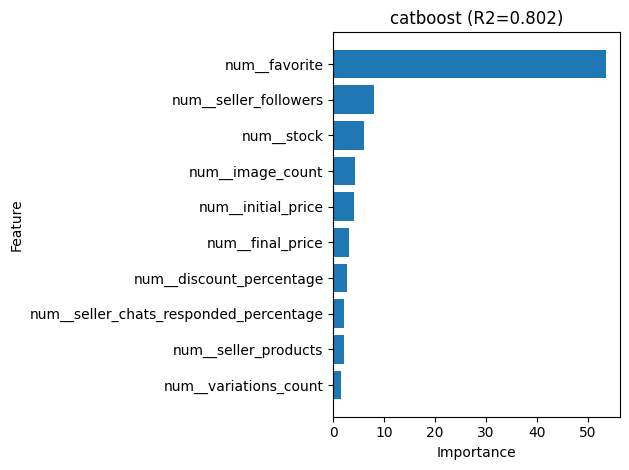

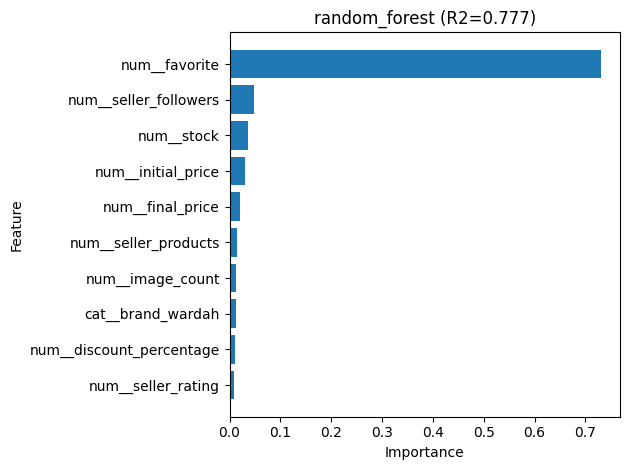

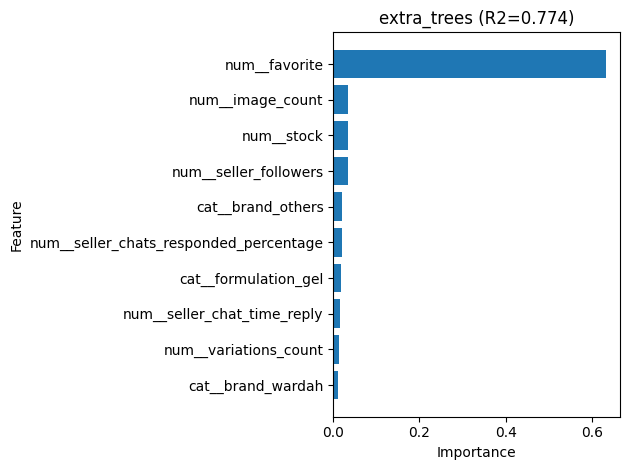


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite   19.078041
                 num__seller_followers    2.838188
                            num__stock    2.104733
                      num__image_count    1.465325
                    num__initial_price    1.401449
                      num__final_price    1.097018
              num__discount_percentage    0.930675
num__seller_chats_responded_percentage    0.768145
                  num__seller_products    0.730954
                 num__variations_count    0.539239


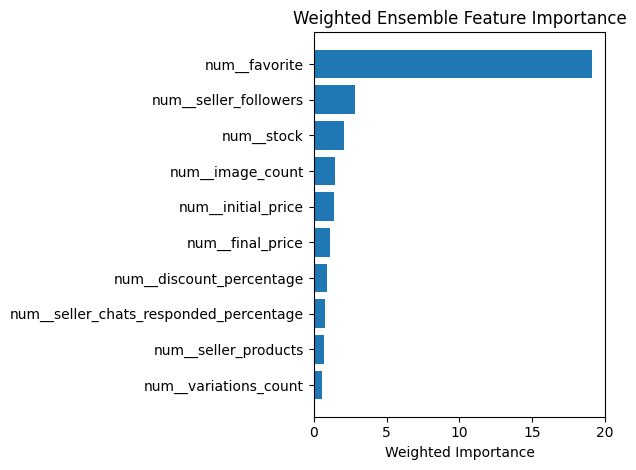


[STAGE] 11. MODEL PERFORMANCE TABLE
        model stage_used     rmse      mae       r2
     ensemble        NaN 0.380648 0.244820 0.804965
     catboost      tuned 0.383922 0.250303 0.801595
random_forest   baseline 0.407259 0.252360 0.776741
  extra_trees      tuned 0.409348 0.267036 0.774445
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 98%|===================| 528/540 [00:29<00:00]        

[INFO] SHAP summary plot generating...


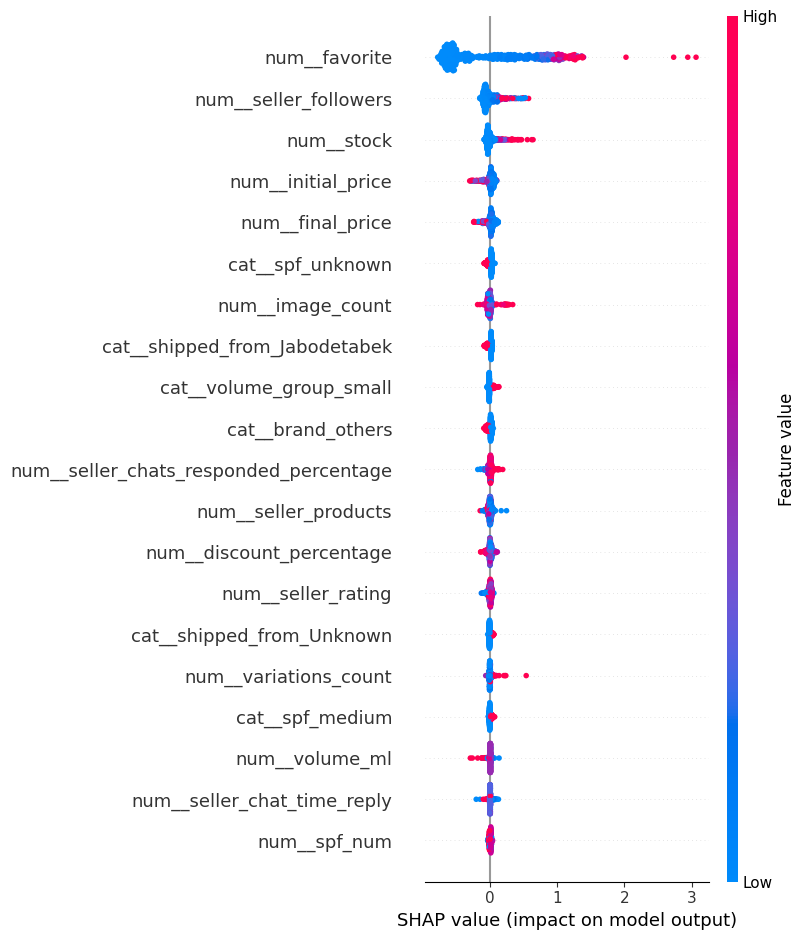


[STAGE] SHAP THRESHOLD ANALYSIS
                      feature       positive_range       negative_range                           recommendation                       interpretation                                insight
                num__favorite     65.00 – 27340.00          0.00 – 4.00                        Increase favorite          favorite ≈ 65.00 – 27340.00 higher values drive better performance
        num__seller_followers    2.00 – 8156548.00    104.00 – 24100.00                Increase seller_followers seller_followers ≈ 2.00 – 8156548.00 higher values drive better performance
                   num__stock  30.00 – 24995859.00        0.00 – 324.00                           Increase stock          stock ≈ 30.00 – 24995859.00 higher values drive better performance
           num__initial_price 15000.00 – 299000.00 2900.00 – 1300000.00                     Reduce initial_price initial_price ≈ 15000.00 – 299000.00  lower values drive better performance
             num__fina

C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

{'results_table':            model stage_used      rmse       mae        r2
 3       ensemble        NaN  0.380648  0.244820  0.804965
 1       catboost      tuned  0.383922  0.250303  0.801595
 2  random_forest   baseline  0.407259  0.252360  0.776741
 0    extra_trees      tuned  0.409348  0.267036  0.774445}

In [112]:
df_sunscreen = df_sunscreen.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_sunscreen)

## SANDAL MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (6400, 43)
[INFO] Validation shape: (1600, 43)
[INFO] Test shape: (2000, 43)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.71697691 0.6963654 ]
[INFO] Weight STD: [0.02226388 0.02288352]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 50.73% ± 1.58%
[INFO] z_rating_credibility: 49.27% ± 1.62%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.716977    0.022264   50.729176 1.575265
z_rating_credibility    0.696365    0.022884   49.270824 1.619106

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 30

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 18
[INFO] # Categorical: 9
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_seller_products', 'log_seller_followers', 'log_initial_price', 'log_stock', 'log_favorite', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_time_reply', 'vari

[I 2026-04-19 23:02:56,023] A new study created in memory with name: no-name-b00f994a-b820-40bd-ac1f-b8ee98198c30



[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.636408    0.021948     0.445365    0.735259
         lightgbm      0.650639    0.025491     0.455153    0.723372
          xgboost      0.675865    0.024248     0.466204    0.701514
      extra_trees      0.685238    0.031274     0.471657    0.693763
    random_forest      0.690544    0.031943     0.477674    0.688719
              svr      0.793495    0.028328     0.526797    0.588379
              knn      0.861435    0.032393     0.591307    0.514627
            ridge      0.933073    0.037217     0.688818    0.432031
linear_regression      0.934324    0.037275     0.689524    0.430527
      elastic_net      1.230763    0.048795     0.929117    0.012588
            lasso      1.239024    0.045993     0.934242   -0.000887
[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-19 23:03:02,700] Trial 0 finished with value: 0.6580290732756198 and parameters: {'iterations': 225, 'depth': 8, 'learning_rate': 0.08321982536603098, 'l2_leaf_reg': 1.8801202194121949, 'border_count': 221}. Best is trial 0 with value: 0.6580290732756198.
[I 2026-04-19 23:03:11,272] Trial 1 finished with value: 0.7676508383254805 and parameters: {'iterations': 339, 'depth': 9, 'learning_rate': 0.012598734555777272, 'l2_leaf_reg': 4.194212844384662, 'border_count': 65}. Best is trial 0 with value: 0.6580290732756198.
[I 2026-04-19 23:03:17,223] Trial 2 finished with value: 0.6590109320855513 and parameters: {'iterations': 681, 'depth': 4, 'learning_rate': 0.120334697425647, 'l2_leaf_reg': 5.655480671640808, 'border_count': 151}. Best is trial 0 with value: 0.6580290732756198.
[I 2026-04-19 23:03:24,933] Trial 3 finished with value: 0.6511472682552553 and parameters: {'iterations': 310, 'depth': 9, 'learning_rate': 0.19100546939694388, 'l2_leaf_reg': 2.6876900976060245, 'borde

[INFO] Best params for catboost: {'iterations': 775, 'depth': 7, 'learning_rate': 0.08543929501387255, 'l2_leaf_reg': 1.8262079754841547, 'border_count': 221}


...

[INFO] Best params for lightgbm: {'n_estimators': 696, 'num_leaves': 70, 'learning_rate': 0.04678706653976983, 'feature_fraction': 0.6300121104111459, 'bagging_fraction': 0.8824573559867435, 'min_child_samples': 20}


[I 2026-04-19 23:43:53,535] A new study created in memory with name: no-name-ac5ecd9e-3b07-4fbf-b77f-c7ef97cdaff1


[INFO] Tuning model: xgboost


[I 2026-04-19 23:43:55,969] Trial 0 finished with value: 0.7053547242566315 and parameters: {'n_estimators': 628, 'max_depth': 4, 'learning_rate': 0.01342569034441316, 'subsample': 0.9627425867689703, 'colsample_bytree': 0.642392490794482, 'gamma': 1.6704992766087745, 'reg_lambda': 0.00928613721324963}. Best is trial 0 with value: 0.7053547242566315.
[I 2026-04-19 23:43:58,989] Trial 1 finished with value: 0.64580933878566 and parameters: {'n_estimators': 556, 'max_depth': 8, 'learning_rate': 0.0679717682368353, 'subsample': 0.7085083511626084, 'colsample_bytree': 0.9875985990796431, 'gamma': 0.20213211933170716, 'reg_lambda': 0.4123648928303628}. Best is trial 1 with value: 0.64580933878566.
[I 2026-04-19 23:44:00,703] Trial 2 finished with value: 0.7192368193617533 and parameters: {'n_estimators': 507, 'max_depth': 5, 'learning_rate': 0.023792441679449813, 'subsample': 0.9713687711665373, 'colsample_bytree': 0.9560952566641264, 'gamma': 4.2119236167957075, 'reg_lambda': 1.74159622123

[INFO] Best params for xgboost: {'n_estimators': 651, 'max_depth': 6, 'learning_rate': 0.05613846125101751, 'subsample': 0.7534615001345215, 'colsample_bytree': 0.8548063807209252, 'gamma': 0.11170505976319939, 'reg_lambda': 6.737592366749084}

Tuning Summary:
   model                                                                                                                                                                                                         best_params
catboost                                                                                       {'iterations': 775, 'depth': 7, 'learning_rate': 0.08543929501387255, 'l2_leaf_reg': 1.8262079754841547, 'border_count': 221}
lightgbm                              {'n_estimators': 696, 'num_leaves': 70, 'learning_rate': 0.04678706653976983, 'feature_fraction': 0.6300121104111459, 'bagging_fraction': 0.8824573559867435, 'min_child_samples': 20}
 xgboost {'n_estimators': 651, 'max_depth': 6, 'learning_rate': 0.0561384612

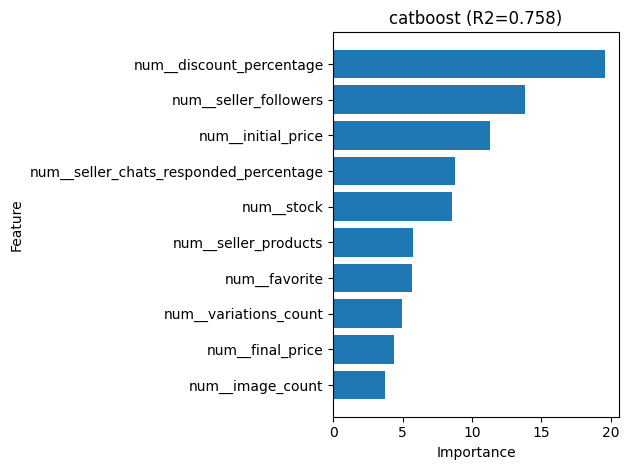

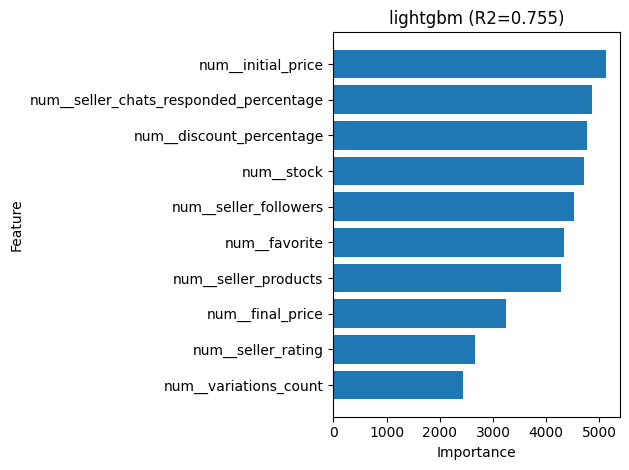

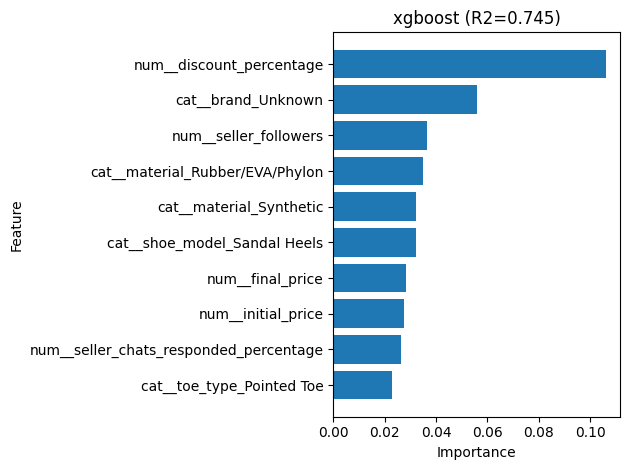


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                    num__initial_price 1720.475073
num__seller_chats_responded_percentage 1626.586909
              num__discount_percentage 1604.502996
                            num__stock 1578.656484
                 num__seller_followers 1514.865119
                         num__favorite 1452.887015
                  num__seller_products 1436.168134
                      num__final_price 1088.360762
                    num__seller_rating  892.352519
                 num__variations_count  814.817838


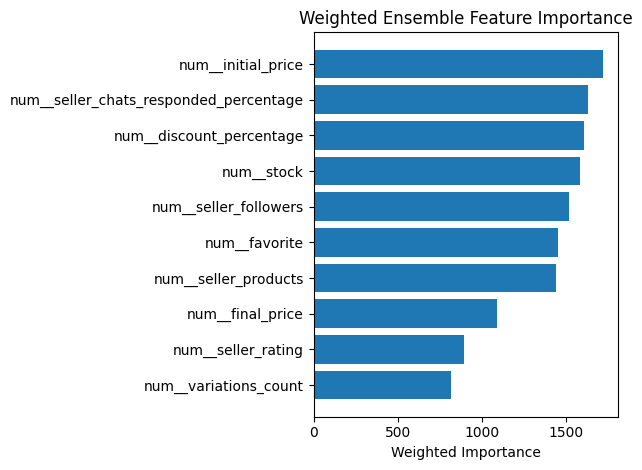


[STAGE] 11. MODEL PERFORMANCE TABLE
   model stage_used     rmse      mae       r2
ensemble        NaN 0.592101 0.412953 0.762846
catboost      tuned 0.597713 0.420827 0.758329
lightgbm      tuned 0.602075 0.416383 0.754788
 xgboost      tuned 0.613690 0.429206 0.745236
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


100%|===================| 996/1000 [01:12<00:00]        

[INFO] SHAP summary plot generating...


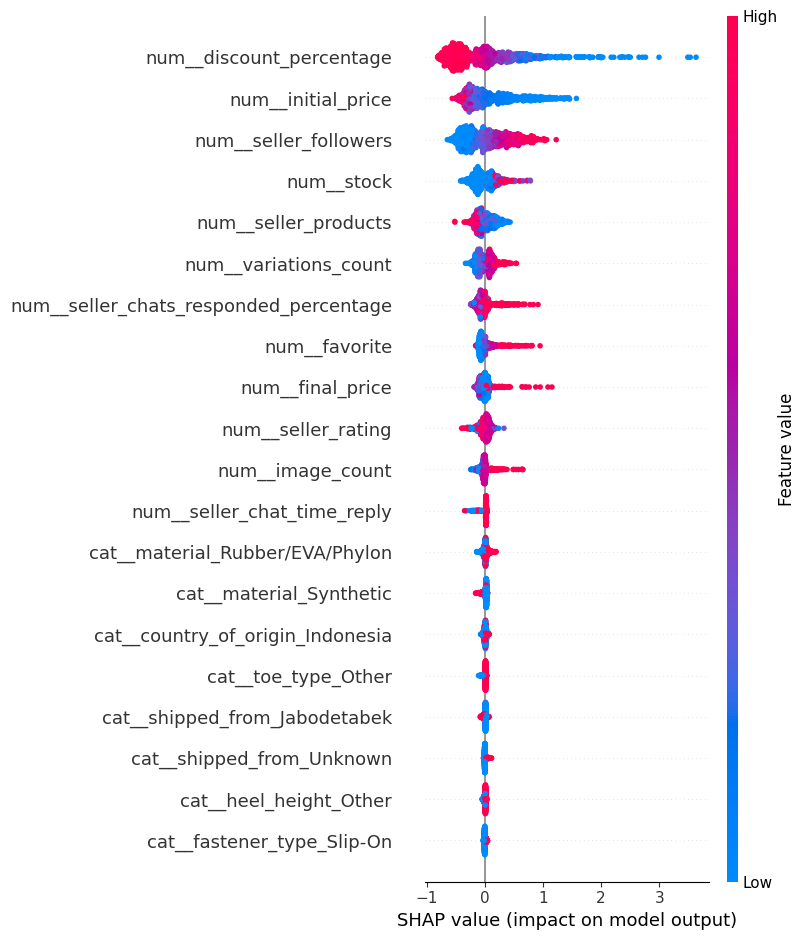


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature        positive_range        negative_range                             recommendation                                     interpretation                                insight
              num__discount_percentage      -590.02 – -16.57         83.33 – 98.52                 Reduce discount_percentage             discount_percentage ≈ -590.02 – -16.57  lower values drive better performance
                    num__initial_price    8000.00 – 45900.00 95800.00 – 1980000.00                       Reduce initial_price                 initial_price ≈ 8000.00 – 45900.00  lower values drive better performance
                 num__seller_followers 168004.70 – 406876.32       0.00 – 44079.57                  Increase seller_followers           seller_followers ≈ 168004.70 – 406876.32 higher values drive better performance
                            num__stock    162.00 – 383833.00          0.00 – 75.00                     

C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

{'results_table':       model stage_used      rmse       mae        r2
 3  ensemble        NaN  0.592101  0.412953  0.762846
 0  catboost      tuned  0.597713  0.420827  0.758329
 1  lightgbm      tuned  0.602075  0.416383  0.754788
 2   xgboost      tuned  0.613690  0.429206  0.745236}

In [116]:
df_sandal = df_sandal.drop(columns=["seller_joined_date", "breadcrumb", "discount"], errors="ignore")
run_pipeline(df_sandal)

## WALLET MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2656, 48)
[INFO] Validation shape: (664, 48)
[INFO] Test shape: (831, 48)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.69784258 0.71535622]
[INFO] Weight STD: [0.02578942 0.02482168]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 49.38% ± 1.82%
[INFO] z_rating_credibility: 50.62% ± 1.76%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.697843    0.025789   49.380355 1.824897
z_rating_credibility    0.715356    0.024822   50.619645 1.756418

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 35

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 13
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_favorite', 'log_final_price', 'log_initial_price', 'log_stock', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_tim

[I 2026-04-19 23:59:04,019] A new study created in memory with name: no-name-f35b33a9-867e-4b57-a5fb-8fb56a9316cc



[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.754655    0.043383     0.455549    0.619356
         lightgbm      0.765802    0.057744     0.457810    0.607108
      extra_trees      0.779270    0.052932     0.451710    0.593725
          xgboost      0.785940    0.052021     0.466925    0.586080
    random_forest      0.788334    0.036362     0.454847    0.584479
              knn      0.886399    0.057494     0.555445    0.474589
              svr      0.893730    0.052921     0.486844    0.467065
            ridge      0.930046    0.049184     0.647422    0.422632
linear_regression      0.932197    0.049140     0.649121    0.419962
      elastic_net      1.177730    0.049536     0.907679    0.074003
            lasso      1.224386    0.047960     0.962559   -0.001033
[INFO] Top models: ['catboost', 'lightgbm', 'extra_trees']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost

[I 2026-04-19 23:59:43,952] Trial 0 finished with value: 0.7647489978803014 and parameters: {'iterations': 517, 'depth': 10, 'learning_rate': 0.02540946215058399, 'l2_leaf_reg': 6.314854000997195, 'border_count': 232}. Best is trial 0 with value: 0.7647489978803014.
[I 2026-04-19 23:59:49,581] Trial 1 finished with value: 0.8189547978017678 and parameters: {'iterations': 354, 'depth': 7, 'learning_rate': 0.010814806302337193, 'l2_leaf_reg': 1.5759443621272147, 'border_count': 198}. Best is trial 0 with value: 0.7647489978803014.
[I 2026-04-19 23:59:54,167] Trial 2 finished with value: 0.8274792474160295 and parameters: {'iterations': 538, 'depth': 5, 'learning_rate': 0.010706985840770072, 'l2_leaf_reg': 5.456291632346852, 'border_count': 232}. Best is trial 0 with value: 0.7647489978803014.
[I 2026-04-19 23:59:57,878] Trial 3 finished with value: 0.7727088534006197 and parameters: {'iterations': 449, 'depth': 5, 'learning_rate': 0.055220394938322, 'l2_leaf_reg': 2.1292744535829313, 'bo

[INFO] Best params for catboost: {'iterations': 652, 'depth': 8, 'learning_rate': 0.11710072071002078, 'l2_leaf_reg': 9.994182673963698, 'border_count': 123}


...

[INFO] Best params for lightgbm: {'n_estimators': 574, 'num_leaves': 95, 'learning_rate': 0.02049674246640295, 'feature_fraction': 0.6281553852719959, 'bagging_fraction': 0.7247872508629742, 'min_child_samples': 9}


[I 2026-04-20 00:48:49,196] A new study created in memory with name: no-name-c87bc514-609d-47d4-8788-c85d1c19eb42


[INFO] Tuning model: extra_trees


[I 2026-04-20 00:50:46,669] Trial 0 finished with value: 0.7957246976545199 and parameters: {'n_estimators': 321, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7957246976545199.
[I 2026-04-20 00:51:24,601] Trial 1 finished with value: 0.7836221827637257 and parameters: {'n_estimators': 101, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7836221827637257.
[I 2026-04-20 00:53:48,407] Trial 2 finished with value: 0.7838137429981687 and parameters: {'n_estimators': 337, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.7836221827637257.
[I 2026-04-20 00:55:37,508] Trial 3 finished with value: 0.7767418804945911 and parameters: {'n_estimators': 173, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.7767418804945911.
[I 2026-04-20 00:56:21,707] Trial 4 finished with value: 0.834746055686475 and parameters: 

[INFO] Best params for extra_trees: {'n_estimators': 247, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 2}

Tuning Summary:
      model                                                                                                                                                                           best_params
   catboost                                                          {'iterations': 652, 'depth': 8, 'learning_rate': 0.11710072071002078, 'l2_leaf_reg': 9.994182673963698, 'border_count': 123}
   lightgbm {'n_estimators': 574, 'num_leaves': 95, 'learning_rate': 0.02049674246640295, 'feature_fraction': 0.6281553852719959, 'bagging_fraction': 0.7247872508629742, 'min_child_samples': 9}
extra_trees                                                                                                 {'n_estimators': 247, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 2}

[STAGE] 9. FINALIZE TOP MODELS
[INFO] Processing: catboost
[INFO] catboost → using t

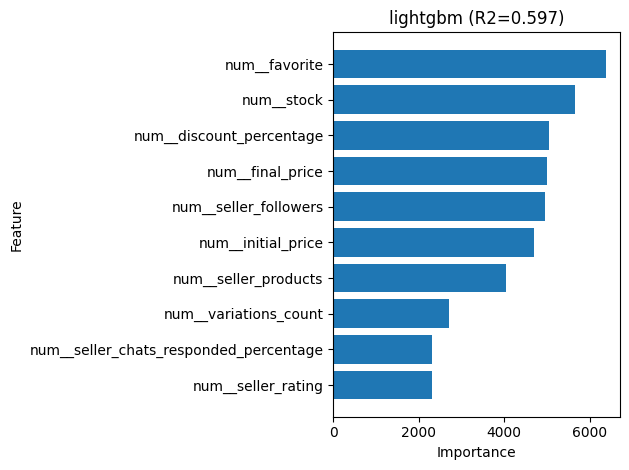

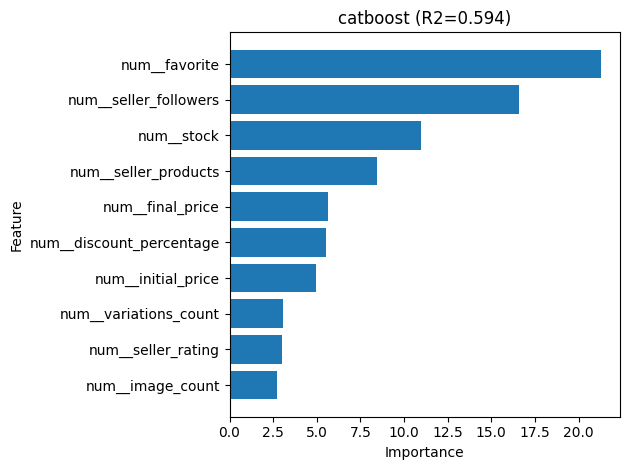

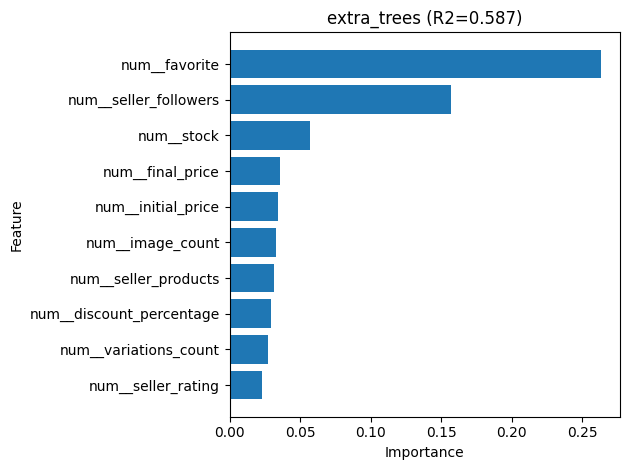


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite 2147.739327
                            num__stock 1901.991356
              num__discount_percentage 1696.463875
                      num__final_price 1675.388496
                 num__seller_followers 1666.020846
                    num__initial_price 1571.641550
                  num__seller_products 1357.378404
                 num__variations_count  910.653372
num__seller_chats_responded_percentage  777.611082
                    num__seller_rating  772.598645


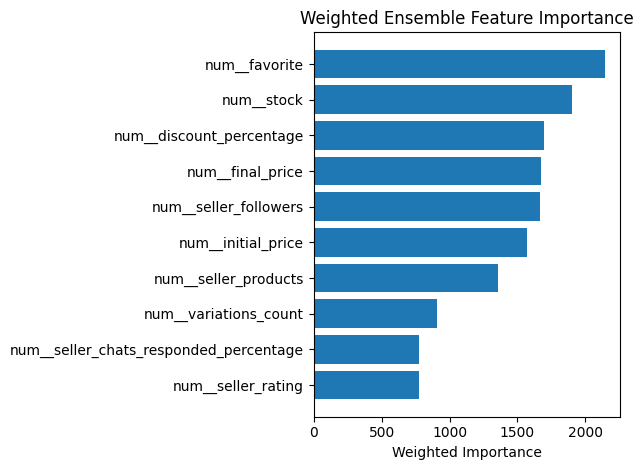


[STAGE] 11. MODEL PERFORMANCE TABLE
      model stage_used     rmse      mae       r2
   ensemble        NaN 0.772341 0.439446 0.611107
   lightgbm      tuned 0.786303 0.454053 0.596919
   catboost      tuned 0.789182 0.461725 0.593962
extra_trees      tuned 0.795523 0.448057 0.587411
[INFO] Best model: lightgbm

[STAGE] 12. SHAP ANALYSIS


100%|===================| 663/664 [00:34<00:00]        

[INFO] SHAP summary plot generating...


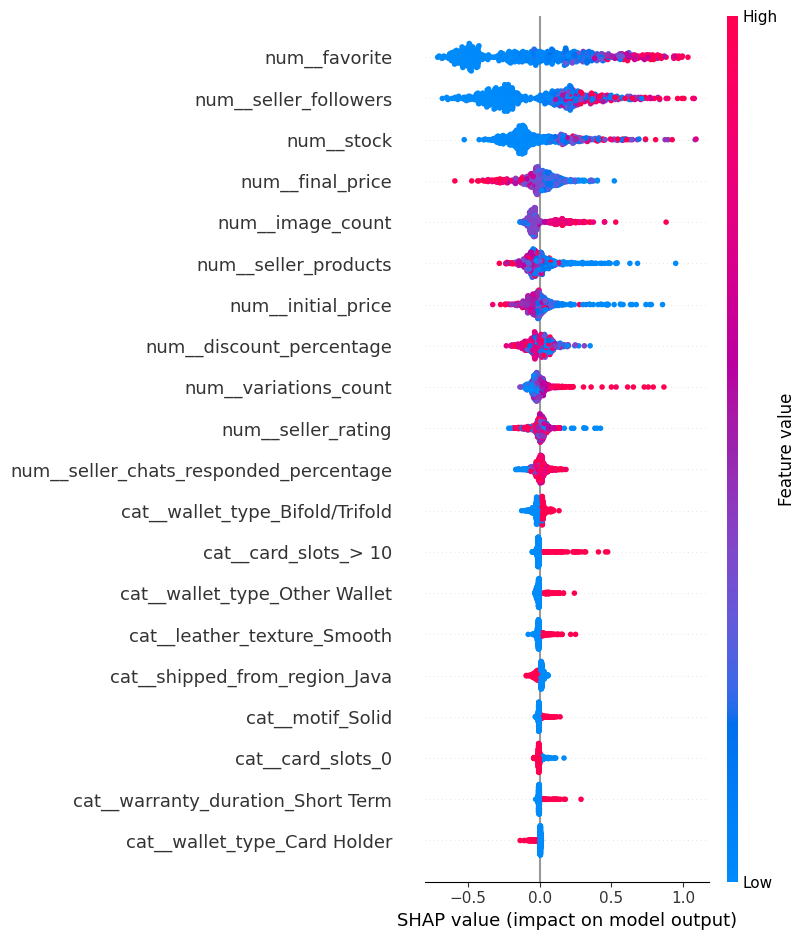


[STAGE] SHAP THRESHOLD ANALYSIS
                 feature       positive_range       negative_range             recommendation                          interpretation                                insight
           num__favorite       40.00 – 997.00         0.00 – 10.00          Increase favorite               favorite ≈ 40.00 – 997.00 higher values drive better performance
   num__seller_followers 28600.00 – 695400.00     20.00 – 26700.00  Increase seller_followers seller_followers ≈ 28600.00 – 695400.00 higher values drive better performance
              num__stock    347.00 – 24899.00        0.00 – 199.00             Increase stock               stock ≈ 347.00 – 24899.00 higher values drive better performance
        num__final_price   3999.00 – 66650.00 70413.00 – 439000.00         Reduce final_price        final_price ≈ 3999.00 – 66650.00  lower values drive better performance
        num__image_count        10.00 – 32.00          4.00 – 8.00       Increase image_count         

C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

{'results_table':          model stage_used      rmse       mae        r2
 3     ensemble        NaN  0.772341  0.439446  0.611107
 1     lightgbm      tuned  0.786303  0.454053  0.596919
 0     catboost      tuned  0.789182  0.461725  0.593962
 2  extra_trees      tuned  0.795523  0.448057  0.587411}

In [117]:
df_wallet = df_wallet.drop(columns=["seller_joined_date", "breadcrumb", "discount", "log_gmv"], errors="ignore")
run_pipeline(df_wallet)

## PAN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2912, 42)
[INFO] Validation shape: (728, 42)
[INFO] Test shape: (911, 42)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.78905645 0.55620888]
[INFO] Weight STD: [0.16945136 0.19826204]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 58.65% ± 12.60%
[INFO] z_rating_credibility: 41.35% ± 14.74%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.789056    0.169451   58.654337 12.596129
z_rating_credibility    0.556209    0.198262   41.345663 14.737765

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 29

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 8
[INFO] # Binary: 2

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat

[I 2026-04-20 03:31:56,251] A new study created in memory with name: no-name-3b062ea3-abba-4c74-8886-795ac13b9dc3



[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.698964    0.243709     0.227755    0.647413
    random_forest      0.737527    0.219870     0.241820    0.608731
          xgboost      0.771125    0.199637     0.245050    0.536896
         lightgbm      0.826805    0.256622     0.264869    0.525720
      extra_trees      0.897481    0.290107     0.264371    0.427632
              knn      0.904324    0.274527     0.290838    0.428931
              svr      0.925102    0.290472     0.262754    0.411445
            ridge      0.986479    0.283208     0.434829    0.324192
linear_regression      0.991773    0.282134     0.443949    0.316313
      elastic_net      1.139018    0.283855     0.521219    0.086091
            lasso      1.187947    0.273632     0.575743   -0.002995
[INFO] Top models: ['catboost', 'random_forest', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboos

[I 2026-04-20 03:31:58,765] Trial 0 finished with value: 0.7675514859668507 and parameters: {'iterations': 370, 'depth': 4, 'learning_rate': 0.027897274949393962, 'l2_leaf_reg': 7.536140770194181, 'border_count': 160}. Best is trial 0 with value: 0.7675514859668507.
[I 2026-04-20 03:32:00,214] Trial 1 finished with value: 0.7238962663831143 and parameters: {'iterations': 202, 'depth': 4, 'learning_rate': 0.08996987627176538, 'l2_leaf_reg': 2.8431627769776604, 'border_count': 255}. Best is trial 1 with value: 0.7238962663831143.
[I 2026-04-20 03:32:06,076] Trial 2 finished with value: 0.7164895271241857 and parameters: {'iterations': 390, 'depth': 7, 'learning_rate': 0.03286290182279957, 'l2_leaf_reg': 3.7565126779236118, 'border_count': 194}. Best is trial 2 with value: 0.7164895271241857.
[I 2026-04-20 03:32:17,654] Trial 3 finished with value: 0.7154841958257354 and parameters: {'iterations': 695, 'depth': 8, 'learning_rate': 0.10497863298898429, 'l2_leaf_reg': 8.124969257705944, 'bo

[INFO] Best params for catboost: {'iterations': 508, 'depth': 4, 'learning_rate': 0.07731932364716948, 'l2_leaf_reg': 1.0934075799716119, 'border_count': 128}


...

[INFO] Best params for random_forest: {'n_estimators': 189, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


[I 2026-04-20 03:57:11,763] A new study created in memory with name: no-name-55c747ab-1296-4d5a-975f-4b468d606481


[INFO] Tuning model: xgboost


[I 2026-04-20 03:57:13,181] Trial 0 finished with value: 0.729808176919577 and parameters: {'n_estimators': 541, 'max_depth': 6, 'learning_rate': 0.019192046319590084, 'subsample': 0.8647913661539315, 'colsample_bytree': 0.7146036038727213, 'gamma': 0.8369045764450878, 'reg_lambda': 0.08578553129998835}. Best is trial 0 with value: 0.729808176919577.
[I 2026-04-20 03:57:14,898] Trial 1 finished with value: 0.691567390419807 and parameters: {'n_estimators': 365, 'max_depth': 10, 'learning_rate': 0.01866718502295591, 'subsample': 0.6767762203320491, 'colsample_bytree': 0.81718994002466, 'gamma': 0.6166850685027658, 'reg_lambda': 0.005175180663240108}. Best is trial 1 with value: 0.691567390419807.
[I 2026-04-20 03:57:17,823] Trial 2 finished with value: 0.7599987992929222 and parameters: {'n_estimators': 334, 'max_depth': 9, 'learning_rate': 0.01024194261145359, 'subsample': 0.7926436662261587, 'colsample_bytree': 0.9931871425823293, 'gamma': 0.2809366652696804, 'reg_lambda': 6.243551168

[INFO] Best params for xgboost: {'n_estimators': 504, 'max_depth': 10, 'learning_rate': 0.047055350759668324, 'subsample': 0.6748798822581511, 'colsample_bytree': 0.6960109977770971, 'gamma': 0.6361577105535977, 'reg_lambda': 0.111584409300526}

Tuning Summary:
        model                                                                                                                                                                                                          best_params
     catboost                                                                                        {'iterations': 508, 'depth': 4, 'learning_rate': 0.07731932364716948, 'l2_leaf_reg': 1.0934075799716119, 'border_count': 128}
random_forest                                                                                                        {'n_estimators': 189, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
      xgboost {'n_estimators': 504, 'max_depth': 10, 'lea

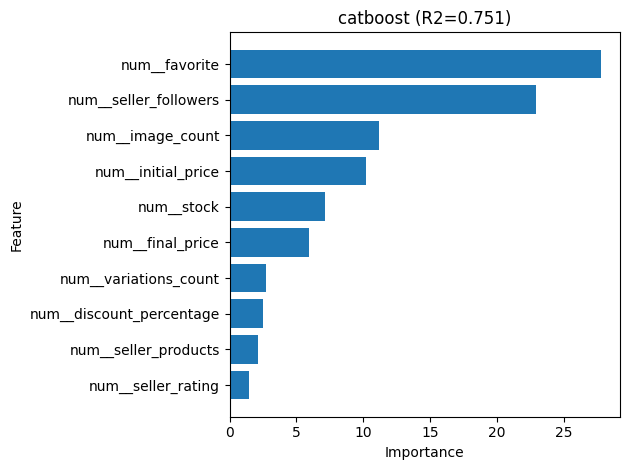

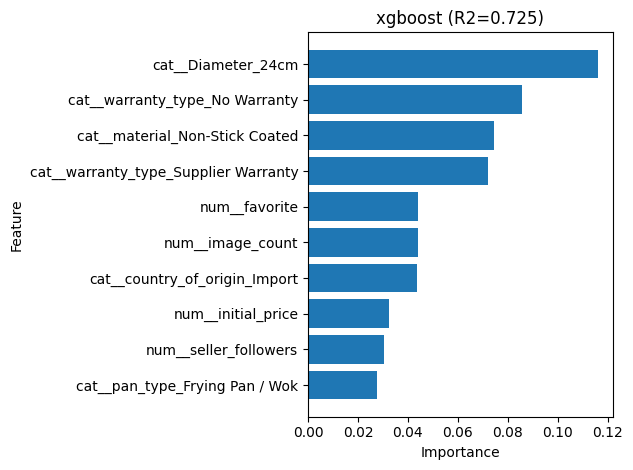

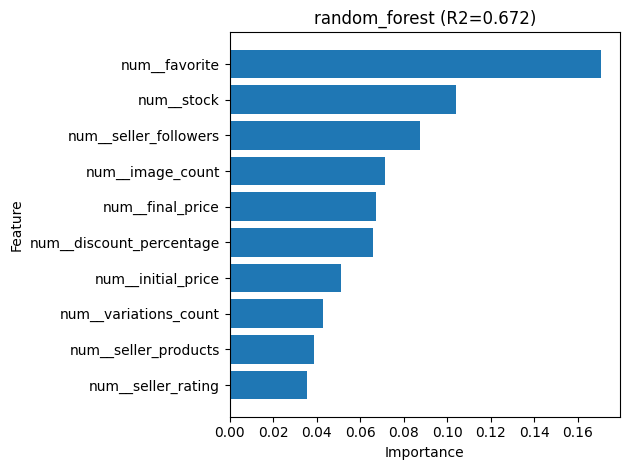


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                 feature  importance
           num__favorite    9.929622
   num__seller_followers    8.154589
        num__image_count    4.004900
      num__initial_price    3.635252
              num__stock    2.580780
        num__final_price    2.143085
   num__variations_count    0.980133
num__discount_percentage    0.916130
    num__seller_products    0.783632
      num__seller_rating    0.520162


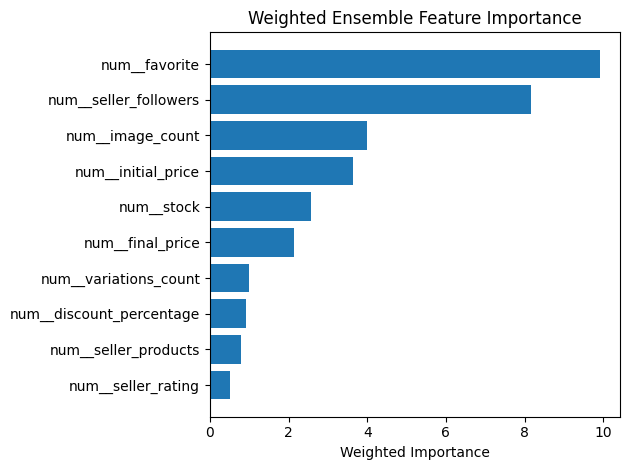


[STAGE] 11. MODEL PERFORMANCE TABLE
        model stage_used     rmse      mae       r2
     catboost   baseline 0.375475 0.186295 0.751240
     ensemble        NaN 0.376287 0.197091 0.750162
      xgboost      tuned 0.395061 0.203515 0.724610
random_forest      tuned 0.430989 0.230809 0.672243
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 99%|===================| 718/728 [00:19<00:00]        

[INFO] SHAP summary plot generating...


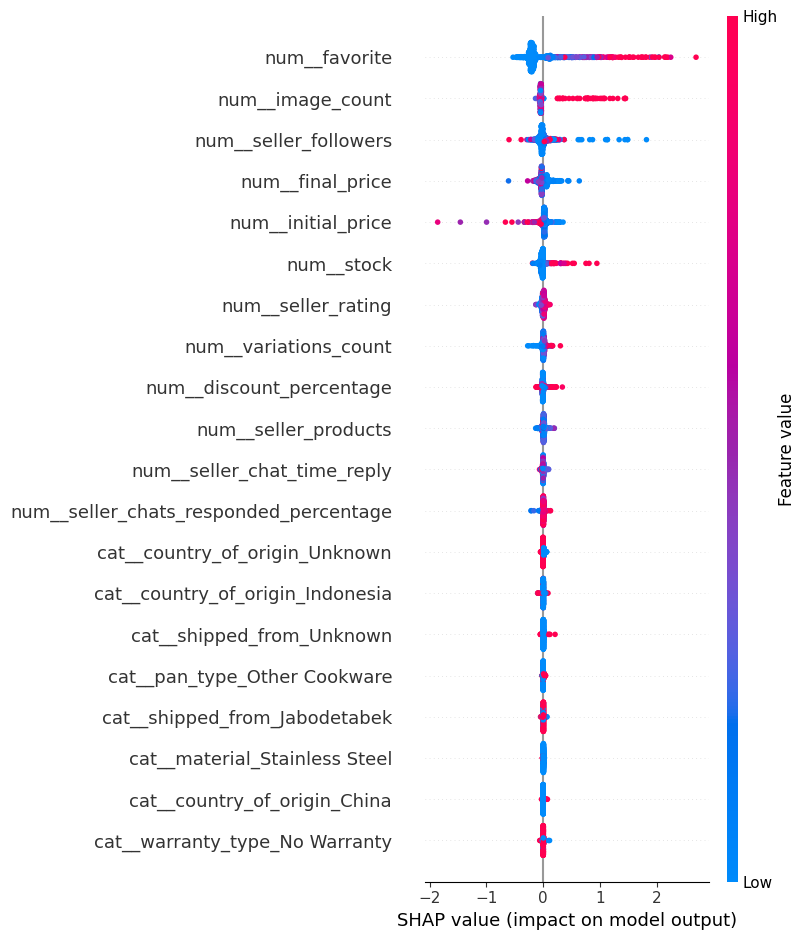


[STAGE] SHAP THRESHOLD ANALYSIS
                 feature      positive_range         negative_range             recommendation                       interpretation                                insight
           num__favorite     15.00 – 4938.00            0.00 – 2.00          Increase favorite           favorite ≈ 15.00 – 4938.00 higher values drive better performance
        num__image_count        2.00 – 17.00            1.00 – 9.00       Increase image_count           image_count ≈ 2.00 – 17.00 higher values drive better performance
   num__seller_followers   0.00 – 1888813.00     126.00 – 970000.00  Increase seller_followers seller_followers ≈ 0.00 – 1888813.00 higher values drive better performance
        num__final_price 8888.00 – 111000.00 120000.00 – 1999000.00         Reduce final_price    final_price ≈ 8888.00 – 111000.00  lower values drive better performance
      num__initial_price 8888.00 – 333000.00  69000.00 – 2580000.00       Reduce initial_price  initial_price ≈ 

C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_9292\1437362299.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

{'results_table':            model stage_used      rmse       mae        r2
 0       catboost   baseline  0.375475  0.186295  0.751240
 3       ensemble        NaN  0.376287  0.197091  0.750162
 2        xgboost      tuned  0.395061  0.203515  0.724610
 1  random_forest      tuned  0.430989  0.230809  0.672243}

In [118]:
df_pan = df_pan.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_pan)